# Day 2: Exploratory Data Analysis (EDA)

Objectives:
- Load and inspect the data.
- Visualize extreme class imbalance.
- Analyze feature skewness for Time and Amount.
- Apply robust scaling to Time and Amount.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load the data
df = pd.read_csv('../data/raw/creditcard.csv')

# Inspect the first few rows and data types
display(df.head())
display(df.info())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

### Visualize the Extreme Class Imbalance

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


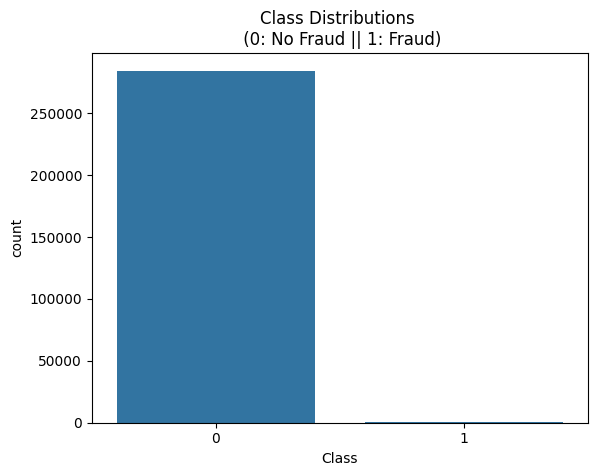

In [6]:
# Check the exact distribution
print(df['Class'].value_counts(normalize=True) * 100)

# Plot the imbalance
sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)')
plt.show()

### Analyze Feature Skewness

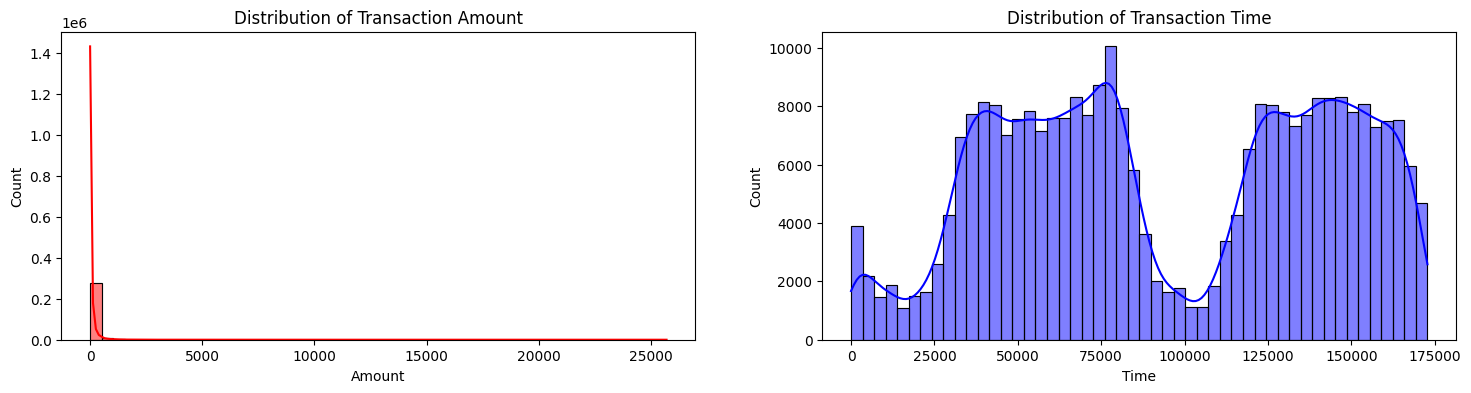

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

sns.histplot(df['Amount'], ax=ax[0], bins=50, kde=True, color='r')
ax[0].set_title('Distribution of Transaction Amount')

sns.histplot(df['Time'], ax=ax[1], bins=50, kde=True, color='b')
ax[1].set_title('Distribution of Transaction Time')

plt.show()

### Apply Robust Scaling

In [8]:
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

# Create new scaled columns
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop the original unscaled columns
df.drop(['Time','Amount'], axis=1, inplace=True)

# Reorder columns so scaled features are at the front (optional but cleaner)
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

display(df.head())

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


# Day 3: Data Splitting and Validation

Objectives:
- Separate features and target.
- Perform a stratified 80/20 split.
- Validate split integrity.

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target label (y)
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

In [ ]:
# Perform the 80/20 split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

In [ ]:
# Function to calculate fraud percentage
def check_fraud_ratio(y_data, dataset_name):
    fraud_count = y_data.sum()
    total_count = len(y_data)
    ratio = (fraud_count / total_count) * 100
    print(f"{dataset_name} Fraud Ratio: {ratio:.3f}% ({fraud_count} frauds out of {total_count} transactions)")

# Validate the splits
check_fraud_ratio(y, "Original Dataset")
check_fraud_ratio(y_train, "Training Set")
check_fraud_ratio(y_test, "Testing Set")

# Day 4: Baseline Model (Logistic Regression - No SMOTE)

Objectives:
- Train a naive Logistic Regression model to establish a performance floor.
- Demonstrate the accuracy paradox on imbalanced data.
- Evaluate using the correct metrics: Precision, Recall, F1, and AUPRC.

## Step 1: Train the Baseline Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate the model
# max_iter is increased to ensure convergence with our dataset size
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the imbalanced training data
baseline_model.fit(X_train, y_train)

print("Baseline model training complete.")

## Step 2: Generate Predictions and Probabilities

In [ ]:
# Generate binary predictions
y_pred = baseline_model.predict(X_test)

# Generate probability scores for the positive class (Fraud)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

## Step 3: Evaluate Using the Correct Metrics

> **Note:** Standard accuracy is a trap for this dataset. We need to look closely at how the model handles the minority class (Class 1 = Fraud).

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Classification Report (Precision, Recall, F1-Score)
print("--- Baseline Model Classification Report ---")
print(classification_report(y_test, y_pred))

# 2. Calculate AUPRC (Area Under the Precision-Recall Curve)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
auprc_score = auc(recall, precision)
print(f"Baseline AUPRC Score: {auprc_score:.4f}\n")

# 3. Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Baseline Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()